# SafeRL-Drive Phase-1 Colab driver

Use this notebook from VS Code with a Google Colab runtime. GitHub and `/content/safedrive` hold the live code. Google Drive holds persistent artifacts only at `/content/drive/MyDrive/SafeDrive`; do not run the repository from mounted Drive.

The smoke test, IDM baseline, PPO training, and SAC training are separate sections so experiments can run in different Colab sessions. After every major experiment, copy its run directory to Drive. Keep the Phase-1 budget fixed; a qualifying checkpoint stops early, while a failed gate should be diagnosed rather than extended blindly.

## 1. Initialization

In [1]:
from pathlib import Path
from datetime import datetime, timezone
import json
import os
import shutil
import subprocess
import sys

REPO_URL = "https://github.com/djdhillxn/safedrive.git"
REPO_DIR = Path("/content/safedrive")
DRIVE_MOUNT = Path("/content/drive")
DRIVE_PROJECT = DRIVE_MOUNT / "MyDrive" / "SafeDrive"
PHASE1_TIMESTEPS = 100_000
TEST_START_SEED = 4000
TEST_EPISODES = 20
VIDEO_STEPS = 1000

print(f"Live checkout: {REPO_DIR}")
print(f"Artifact backup: {DRIVE_PROJECT}")
print(f"Maximum Phase-1 timesteps: {PHASE1_TIMESTEPS:,}")

Live checkout: /content/safedrive
Artifact backup: /content/drive/MyDrive/SafeDrive
Maximum Phase-1 timesteps: 100,000


## 2. Runtime and GPU check

In [2]:
import torch

print(f"Python: {sys.version.split()[0]}")
if shutil.which("nvidia-smi"):
    subprocess.run(
        ["nvidia-smi", "--query-gpu=name,memory.total", "--format=csv,noheader"], check=False
    )
else:
    print("nvidia-smi: unavailable")

if torch.cuda.is_available():
    print(f"PyTorch CUDA: available ({torch.cuda.get_device_name(0)})")
else:
    print("PyTorch CUDA: unavailable; MLP training can still run on CPU.")

Python: 3.12.13
PyTorch CUDA: available (NVIDIA L4)


## 3. Mount Google Drive

In [3]:
from google.colab import drive

drive.mount(str(DRIVE_MOUNT))
DRIVE_PROJECT.mkdir(parents=True, exist_ok=True)
connection_file = DRIVE_PROJECT / "colab_connection_test.txt"
connection_file.write_text(
    f"Connected at {datetime.now(timezone.utc).isoformat()}\n",
    encoding="utf-8",
)
print(f"Drive read/write ready: {connection_file}")

Mounted at /content/drive
Drive read/write ready: /content/drive/MyDrive/SafeDrive/colab_connection_test.txt


## 4. Clone or pull the repository

The repository is public, so no GitHub token is required. Push local changes before this step when Colab needs the newest revision.

In [4]:
if (REPO_DIR / ".git").exists():
    git_command = ["git", "-C", str(REPO_DIR), "pull", "--ff-only"]
elif REPO_DIR.exists() and any(REPO_DIR.iterdir()):
    raise RuntimeError(f"{REPO_DIR} exists but is not a Git repository.")
else:
    if REPO_DIR.exists():
        REPO_DIR.rmdir()
    git_command = ["git", "clone", "--depth", "1", REPO_URL, str(REPO_DIR)]

git_result = subprocess.run(git_command, capture_output=True, text=True)
if git_result.returncode:
    print(git_result.stdout[-4000:])
    print(git_result.stderr[-4000:])
    raise RuntimeError("Git clone/pull failed; see the output above.")

os.chdir(REPO_DIR)
if str(REPO_DIR) not in sys.path:
    sys.path.insert(0, str(REPO_DIR))
git_commit = subprocess.check_output(
    ["git", "-C", str(REPO_DIR), "rev-parse", "HEAD"], text=True
).strip()
print(f"Repository ready at commit {git_commit[:12]}")

Repository ready at commit 87af637c3fea


## 4.1 Restore run artifacts from Drive

Run the shared Drive-to-local sync command. In Colab this performs a full restore, including model files required for evaluation and videos, into `/content/safedrive/runs`. On your Mac, `python -m scripts.sync_drive_runs` defaults to a lightweight analysis-only mirror containing configs, metrics, logs, plots, and videos. Both uses preserve local-only files and rebuild latest-run pointers.

In [5]:
subprocess.run(
    [
        sys.executable,
        "-m",
        "scripts.sync_drive_runs",
        "--drive-project",
        str(DRIVE_PROJECT),
        "--local-runs",
        str(REPO_DIR / "runs"),
        "--include-training-artifacts",
    ],
    cwd=REPO_DIR,
    check=True,
)

CompletedProcess(args=['/usr/bin/python3', '-m', 'scripts.sync_drive_runs', '--drive-project', '/content/drive/MyDrive/SafeDrive', '--local-runs', '/content/safedrive/runs', '--include-training-artifacts'], returncode=0)

## 5. Install SafeRL-Drive

In [6]:
import importlib.metadata

subprocess.run(
    [sys.executable, "-m", "pip", "uninstall", "-y", "gym"],
    check=False,
    capture_output=True,
    text=True,
)
install_result = subprocess.run(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--disable-pip-version-check",
        "--progress-bar",
        "off",
        "-e",
        ".",
    ],
    cwd=REPO_DIR,
    capture_output=True,
    text=True,
)
if install_result.returncode:
    print(install_result.stdout[-8000:])
    print(install_result.stderr[-8000:])
    raise RuntimeError("SafeRL-Drive installation failed; see the output above.")

packages = ["metadrive-simulator", "stable-baselines3", "gymnasium", "torch"]
versions = {name: importlib.metadata.version(name) for name in packages}
print(json.dumps(versions, indent=2))

{
  "metadrive-simulator": "0.4.3",
  "stable-baselines3": "2.9.0",
  "gymnasium": "1.3.0",
  "torch": "2.11.0+cu128"
}


### Shared artifact helpers

In [7]:
def read_latest_run(name):
    pointer = REPO_DIR / "runs" / f"latest_{name}.txt"
    if not pointer.exists():
        raise FileNotFoundError(f"Latest-run pointer not found: {pointer}")
    run_dir = Path(pointer.read_text(encoding="utf-8").strip())
    if not run_dir.is_absolute():
        run_dir = REPO_DIR / run_dir
    return run_dir.resolve()


def require_shell_success(label):
    exit_code = get_ipython().user_ns.get("_exit_code", 0)
    if exit_code:
        raise RuntimeError(f"{label} failed with exit code {exit_code}.")


def require_phase1_metrics(
    summary, label, minimum_success=0.80, minimum_route=0.90,
    maximum_collision=0.10, maximum_off_road=0.10, maximum_timeout=0.10,
):
    success = float(summary.get("success_rate", 0.0))
    route = float(summary.get("mean_route_completion", 0.0))
    collision = float(summary.get("collision_rate", 1.0))
    off_road = float(summary.get("out_of_road_rate", 1.0))
    timeout = float(summary.get("timeout_or_max_step_rate", 1.0))
    if (
        success < minimum_success or route < minimum_route
        or collision > maximum_collision or off_road > maximum_off_road
        or timeout > maximum_timeout
    ):
        raise RuntimeError(
            f"{label} did not qualify: success={success:.1%}, route={route:.1%}, "
            f"collision={collision:.1%}, off-road={off_road:.1%}, timeout={timeout:.1%}. "
            "Keep the task fixed and inspect this run before another experiment."
        )
    print(
        f"{label} qualified: success={success:.1%}, route={route:.1%}, "
        f"collision={collision:.1%}, off-road={off_road:.1%}, timeout={timeout:.1%}."
    )
    return summary


def require_learning_gate(run_dir, label):
    summary_path = Path(run_dir) / "eval" / "best_validation_summary.json"
    summary = json.loads(summary_path.read_text(encoding="utf-8"))
    require_phase1_metrics(summary, f"{label} Phase-1 validation")
    diagnostics_path = Path(run_dir) / "logs" / "training_diagnostics.json"
    if diagnostics_path.exists():
        history = json.loads(diagnostics_path.read_text(encoding="utf-8")).get("history", [])
        critic_losses = [row.get("train/critic_loss") for row in history]
        critic_losses = [float(value) for value in critic_losses if value is not None]
        if critic_losses and (
            not all(value == value and abs(value) != float("inf") for value in critic_losses)
            or abs(critic_losses[-1]) > 1000
        ):
            raise RuntimeError(
                f"{label} Phase-1 critic is unstable: final loss {critic_losses[-1]:.3g}."
            )
    return summary


def show_json(path):
    path = Path(path)
    print(json.dumps(json.loads(path.read_text(encoding="utf-8")), indent=2))


def copy_to_drive(path, category="runs"):
    path = Path(path)
    target = DRIVE_PROJECT / category / path.name
    target.parent.mkdir(parents=True, exist_ok=True)
    if path.is_dir():
        target.mkdir(parents=True, exist_ok=True)
        if shutil.which("rsync"):
            subprocess.run(["rsync", "-a", f"{path}/", f"{target}/"], check=True)
        else:
            shutil.copytree(path, target, dirs_exist_ok=True)
    else:
        shutil.copy2(path, target)
    print(f"Copied to Drive: {target}")
    return target

## 6. Smoke test

This is only an installation/wiring check and is not a report result.

In [7]:
!python -m scripts.train --config configs/smoke_test.yaml
require_shell_success("Smoke test")

SMOKE_RUN_DIR = read_latest_run("smoke")
!python -m scripts.evaluate --run-dir "{SMOKE_RUN_DIR}" --model best --split test --episodes 2 --prefix best_test
require_shell_success("Smoke held-out evaluation")
show_json(SMOKE_RUN_DIR / "eval" / "best_test_summary.json")
copy_to_drive(SMOKE_RUN_DIR, category="smoke_tests")

2026-07-21 21:49:35.714158: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-21 21:49:35.783932: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
INFO: Runtime: Python 3.12.13 | CUDA available | GPU NVIDIA L4
INFO: Run directory: runs/20260721_214939_smoke_test_ppo_seed0
<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
<frozen importlib._bootstrap_external>:1301: Fu

PosixPath('/content/drive/MyDrive/SafeDrive/smoke_tests/20260721_214939_smoke_test_ppo_seed0')

## 7. Deterministic IDM reproducibility gate

In [8]:
!python -m scripts.evaluate_baseline --config configs/ppo_mvp.yaml --split validation --episodes 10 --prefix idm_repro --verify-repeat
require_shell_success("IDM reproducibility gate")
print(
    "IDM reproducibility gate passed. The held-out IDM test runs after both learned configurations are frozen."
)

2026-07-21 21:52:13.717972: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-21 21:52:13.786808: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
INFO: Runtime: Python 3.12.13 | CUDA available | GPU NVIDIA L4
INFO: Run directory: runs/20260721_215217_idm_baseline_seed0
INFO: Evaluating IDMPolicy for 10 episodes on the validation split beginning at seed 1000.
<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use 

## 7.1 Phase-1 learning controls

Run the Phase-1 learning controls here. They use one straight road, no traffic, and MetaDrive's reference reward. PPO uses MetaDrive's beginner 3-by-3 discrete steering/throttle grid; SAC remains continuous with steering limited to [-0.1, 0.1]. A result qualifies only if its best checkpoint reaches at least 80% success and 90% route completion with at most 10% collision, off-road, and timeout outcomes on fixed validation seeds. These algorithm-specific controls prove pipeline competence; they are not a fair PPO-versus-SAC ranking. Continuous PPO, unrestricted SAC, curves, procedural roads, and traffic are later difficulty levels.

In [22]:
# Historical PPO path output retained below; the next cell creates the current run.

PosixPath('/content/safedrive/runs/20260721_215328_ppo_control_pilot_ppo_seed0')

In [8]:
!python -m scripts.train --config configs/ppo_mvp.yaml --run-name ppo_phase1_control train.total_timesteps={PHASE1_TIMESTEPS}
require_shell_success("PPO Phase-1 control")
PPO_RUN_DIR = read_latest_run("ppo")
copy_to_drive(PPO_RUN_DIR)
require_learning_gate(PPO_RUN_DIR, "PPO")

2026-07-22 01:24:39.858985: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-22 01:24:39.929295: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
INFO: Runtime: Python 3.12.13 | CUDA available | GPU NVIDIA L4
INFO: Run directory: runs/20260722_012443_ppo_phase1_control_ppo_seed0
<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
<frozen importlib._bootstrap_external>:

{'episodes': 10,
 'mean_return': 106.31503398443833,
 'std_return': 12.519450508887386,
 'mean_length': 80.5,
 'success_rate': 1.0,
 'success_rate_95ci_low': 0.7224672001371107,
 'success_rate_95ci_high': 0.9999999999999999,
 'collision_rate': 0.0,
 'out_of_road_rate': 0.0,
 'timeout_or_max_step_rate': 0.0,
 'mean_cost': 0.0,
 'mean_route_completion': 0.9640913489345417,
 'mean_base_return': 106.31503398443833,
 'mean_shaping_penalty': 0.0,
 'mean_steering': 0.0,
 'mean_abs_steering': 0.0,
 'steering_saturation_rate': 0.0,
 'mean_throttle_brake': 1.0,
 'throttle_rate': 1.0,
 'brake_rate': 0.0,
 'mean_action_change': 0.0,
 'mean_speed_km_h': 11.896416390256}

In [18]:
# Historical restore output retained below. Use Section 4.1 to restore Drive runs.

Drive source: /content/drive/MyDrive/SafeDrive/runs
Local destination: /content/safedrive/runs
Sync complete: 267 files updated across 9 run directories.
Latest IDM: /content/safedrive/runs/20260721_181208_idm_baseline_seed0
Latest PPO: /content/safedrive/runs/20260721_090542_ppo_mvp_ppo_seed0
Latest PPO_PILOT: /content/safedrive/runs/20260721_215328_ppo_control_pilot_ppo_seed0
Latest SAC: /content/safedrive/runs/20260721_105717_sac_mvp_sac_seed0
Latest SMOKE: /content/safedrive/runs/20260721_214939_smoke_test_ppo_seed0


In [9]:
!python -m scripts.train --config configs/sac_mvp.yaml --run-name sac_phase1_control train.total_timesteps={PHASE1_TIMESTEPS}
require_shell_success("SAC Phase-1 control")
SAC_RUN_DIR = read_latest_run("sac")
copy_to_drive(SAC_RUN_DIR)
require_learning_gate(SAC_RUN_DIR, "SAC")

2026-07-22 01:26:34.604348: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-22 01:26:34.674302: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
INFO: Runtime: Python 3.12.13 | CUDA available | GPU NVIDIA L4
INFO: Run directory: runs/20260722_012638_sac_phase1_control_sac_seed0
<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
<frozen importlib._bootstrap_external>:

{'episodes': 10,
 'mean_return': 106.8082887612934,
 'std_return': 12.542567742857557,
 'mean_length': 113.1,
 'success_rate': 1.0,
 'success_rate_95ci_low': 0.7224672001371107,
 'success_rate_95ci_high': 0.9999999999999999,
 'collision_rate': 0.0,
 'out_of_road_rate': 0.0,
 'timeout_or_max_step_rate': 0.0,
 'mean_cost': 0.0,
 'mean_route_completion': 0.9571211337645649,
 'mean_base_return': 106.8082887612934,
 'mean_shaping_penalty': 0.0,
 'mean_steering': -0.00235756828308897,
 'mean_abs_steering': 0.021616330445045035,
 'steering_saturation_rate': 0.0,
 'mean_throttle_brake': 0.39560127242096244,
 'throttle_rate': 0.8980860693449546,
 'brake_rate': 0.046452023282680555,
 'mean_action_change': 0.030671779831763925,
 'mean_speed_km_h': 8.334136299030563}

## 8. Inspect the qualifying PPO result

In [10]:
PPO_RUN_DIR = read_latest_run("ppo")
require_learning_gate(PPO_RUN_DIR, "PPO")
ppo_summary = PPO_RUN_DIR / "eval" / "best_validation_summary.json"
print(f"PPO run: {PPO_RUN_DIR}")
print(f"PPO summary: {ppo_summary}")
show_json(ppo_summary)
copy_to_drive(PPO_RUN_DIR)

PPO Phase-1 validation qualified: success=100.0%, route=96.4%, collision=0.0%, off-road=0.0%, timeout=0.0%.
PPO run: /content/safedrive/runs/20260722_012443_ppo_phase1_control_ppo_seed0
PPO summary: /content/safedrive/runs/20260722_012443_ppo_phase1_control_ppo_seed0/eval/best_validation_summary.json
{
  "episodes": 10,
  "mean_return": 106.31503398443833,
  "std_return": 12.519450508887386,
  "mean_length": 80.5,
  "success_rate": 1.0,
  "success_rate_95ci_low": 0.7224672001371107,
  "success_rate_95ci_high": 0.9999999999999999,
  "collision_rate": 0.0,
  "out_of_road_rate": 0.0,
  "timeout_or_max_step_rate": 0.0,
  "mean_cost": 0.0,
  "mean_route_completion": 0.9640913489345417,
  "mean_base_return": 106.31503398443833,
  "mean_shaping_penalty": 0.0,
  "mean_steering": 0.0,
  "mean_abs_steering": 0.0,
  "steering_saturation_rate": 0.0,
  "mean_throttle_brake": 1.0,
  "throttle_rate": 1.0,
  "brake_rate": 0.0,
  "mean_action_change": 0.0,
  "mean_speed_km_h": 11.896416390256
}
Copied 

PosixPath('/content/drive/MyDrive/SafeDrive/runs/20260722_012443_ppo_phase1_control_ppo_seed0')

## 9. Inspect the qualifying SAC result

In [11]:
SAC_RUN_DIR = read_latest_run("sac")
require_learning_gate(SAC_RUN_DIR, "SAC")
sac_summary = SAC_RUN_DIR / "eval" / "best_validation_summary.json"
print(f"SAC run: {SAC_RUN_DIR}")
print(f"SAC summary: {sac_summary}")
show_json(sac_summary)
copy_to_drive(SAC_RUN_DIR)

SAC Phase-1 validation qualified: success=100.0%, route=95.7%, collision=0.0%, off-road=0.0%, timeout=0.0%.
SAC run: /content/safedrive/runs/20260722_012638_sac_phase1_control_sac_seed0
SAC summary: /content/safedrive/runs/20260722_012638_sac_phase1_control_sac_seed0/eval/best_validation_summary.json
{
  "episodes": 10,
  "mean_return": 106.8082887612934,
  "std_return": 12.542567742857557,
  "mean_length": 113.1,
  "success_rate": 1.0,
  "success_rate_95ci_low": 0.7224672001371107,
  "success_rate_95ci_high": 0.9999999999999999,
  "collision_rate": 0.0,
  "out_of_road_rate": 0.0,
  "timeout_or_max_step_rate": 0.0,
  "mean_cost": 0.0,
  "mean_route_completion": 0.9571211337645649,
  "mean_base_return": 106.8082887612934,
  "mean_shaping_penalty": 0.0,
  "mean_steering": -0.00235756828308897,
  "mean_abs_steering": 0.021616330445045035,
  "steering_saturation_rate": 0.0,
  "mean_throttle_brake": 0.39560127242096244,
  "throttle_rate": 0.8980860693449546,
  "brake_rate": 0.04645202328268

PosixPath('/content/drive/MyDrive/SafeDrive/runs/20260722_012638_sac_phase1_control_sac_seed0')

## 10. Inspect held-out PPO and SAC tests

Training freezes the best validation checkpoint without touching the held-out test. Run this once after both Phase-1 configurations qualify; it also backfills an older run if needed. This cell enforces the same success, route, collision, off-road, and timeout criteria on seeds 4000--4019, the untouched test set. Seeds 3000--3019 were consumed during local diagnosis.

In [12]:
PPO_RUN_DIR = read_latest_run("ppo")
SAC_RUN_DIR = read_latest_run("sac")

print(PPO_RUN_DIR, SAC_RUN_DIR)

/content/safedrive/runs/20260722_012443_ppo_phase1_control_ppo_seed0 /content/safedrive/runs/20260722_012638_sac_phase1_control_sac_seed0


In [13]:
PPO_RUN_DIR = read_latest_run("ppo")
SAC_RUN_DIR = read_latest_run("sac")

idm_pointer = REPO_DIR / "runs" / "latest_idm.txt"
idm_test_ready = False
if idm_pointer.exists():
    IDM_RUN_DIR = Path(idm_pointer.read_text(encoding="utf-8").strip())
    if not IDM_RUN_DIR.is_absolute():
        IDM_RUN_DIR = REPO_DIR / IDM_RUN_DIR
    idm_test_ready = (IDM_RUN_DIR / "eval" / "idm_test_summary.json").exists()
if not idm_test_ready:
    !python -m scripts.evaluate_baseline --config configs/ppo_mvp.yaml --split test --episodes {TEST_EPISODES} --prefix idm_test
    require_shell_success("IDM held-out test")
    IDM_RUN_DIR = read_latest_run("idm")
show_json(IDM_RUN_DIR / "eval" / "idm_test_summary.json")
copy_to_drive(IDM_RUN_DIR)

for label, run_dir in [("PPO", PPO_RUN_DIR), ("SAC", SAC_RUN_DIR)]:
    test_summary = run_dir / "eval" / "best_test_summary.json"
    if not test_summary.exists():
        # Backfill old runs that predate the validation/test split.
        !python -m scripts.evaluate --run-dir "{run_dir}" --model best --split test --episodes {TEST_EPISODES} --prefix best_test test.start_seed={TEST_START_SEED} test.num_scenarios={TEST_EPISODES} test.random_traffic=false test.random_spawn_lane_index=false
        require_shell_success(f"{label} held-out test evaluation")
    print(f"{label} held-out result: {test_summary}")
    summary = json.loads(test_summary.read_text(encoding="utf-8"))
    require_phase1_metrics(summary, f"{label} held-out test")
    show_json(test_summary)

copy_to_drive(PPO_RUN_DIR)
copy_to_drive(SAC_RUN_DIR)

{
  "episodes": 100,
  "mean_return": 403.3026447561248,
  "std_return": 204.3355870605433,
  "mean_length": 550.77,
  "success_rate": 0.38,
  "success_rate_95ci_low": 0.29097599252478734,
  "success_rate_95ci_high": 0.47790244704488916,
  "collision_rate": 0.56,
  "out_of_road_rate": 0.02,
  "timeout_or_max_step_rate": 0.04,
  "mean_cost": 0.58,
  "mean_route_completion": 0.7057871321959969,
  "mean_speed_km_h": 7.487241073782172
}
Copied to Drive: /content/drive/MyDrive/SafeDrive/runs/20260721_181208_idm_baseline_seed0
2026-07-22 01:41:42.882083: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-22 01:41:42.952026: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical oper

PosixPath('/content/drive/MyDrive/SafeDrive/runs/20260722_012638_sac_phase1_control_sac_seed0')

## 11. Record one rollout per trained agent

The notebook chooses a successful held-out scenario when one exists, otherwise the test scenario with the greatest route completion. The exact seed and outcome are saved beside the MP4.

In [14]:
import csv

PPO_RUN_DIR = read_latest_run("ppo")
SAC_RUN_DIR = read_latest_run("sac")


def choose_video_seed(run_dir):
    episode_path = run_dir / "eval" / "best_test_episodes.csv"
    with episode_path.open(newline="", encoding="utf-8") as file:
        rows = list(csv.DictReader(file))
    successful = [row for row in rows if row["success"].lower() == "true"]
    candidates = successful or rows
    selected = max(candidates, key=lambda row: float(row["route_completion"]))
    return int(float(selected["env_seed"])), bool(successful)


for label, run_dir in [("PPO", PPO_RUN_DIR), ("SAC", SAC_RUN_DIR)]:
    video_seed, is_success = choose_video_seed(run_dir)
    print(f"{label} video seed: {video_seed}; successful test rollout: {is_success}")
    !python -m scripts.record_video --run-dir "{run_dir}" --model best --seed {video_seed} --steps {VIDEO_STEPS}
    require_shell_success(f"{label} video")
    copy_to_drive(run_dir)

PPO video seed: 4001; successful test rollout: True
2026-07-22 01:42:39.892637: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-22 01:42:39.961067: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
INFO: Runtime: Python 3.12.13 | CUDA available | GPU NVIDIA L4
<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
INFO: Loading best model on cpu for deterministic scenario

RuntimeError: PPO video failed with exit code 1.

## 12. Compare IDM, PPO, and SAC

INFO: Runtime: Python 3.12.13 | CUDA available | GPU NVIDIA L4
INFO: Phase-1 comparison written: runs/phase1_comparison.csv
INFO: Comparison plot written: runs/phase1_comparison.png
INFO: Training comparison written: runs/phase1_training_returns.png


,name,episodes,mean_return,std_return,mean_length,success_rate,success_rate_95ci_low,success_rate_95ci_high,collision_rate,out_of_road_rate,...,mean_shaping_penalty,mean_steering,mean_abs_steering,steering_saturation_rate,mean_throttle_brake,throttle_rate,brake_rate,mean_action_change,run_dir,summary_path
0,IDM,100,403.302645,204.335587,550.77,0.38,0.290976,0.477902,0.56,0.02,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,/content/safedrive/runs/20260721_181208_idm_ba...,/content/safedrive/runs/20260721_181208_idm_ba...
1,PPO,20,109.985435,11.363103,82.45,1.00,0.838875,1.000000,0.00,0.00,...,0.0,0.000000,0.000000,0.0,1.000000,1.000000,0.000000,0.000000,/content/safedrive/runs/20260722_012443_ppo_ph...,/content/safedrive/runs/20260722_012443_ppo_ph...
2,SAC,20,110.838025,11.440561,116.75,1.00,0.838875,1.000000,0.00,0.00,...,0.0,-0.002139,0.022213,0.0,0.386564,0.880952,0.043592,0.031154,/content/safedrive/runs/20260722_012638_sac_ph...,/content/safedrive/runs/20260722_012638_sac_ph...


{
  "generated_at_utc": "2026-07-22T01:42:54.144904+00:00",
  "experiments": [
    {
      "name": "IDM",
      "episodes": 100,
      "mean_return": 403.3026447561248,
      "std_return": 204.3355870605433,
      "mean_length": 550.77,
      "success_rate": 0.38,
      "success_rate_95ci_low": 0.29097599252478734,
      "success_rate_95ci_high": 0.47790244704488916,
      "collision_rate": 0.56,
      "out_of_road_rate": 0.02,
      "timeout_or_max_step_rate": 0.04,
      "mean_cost": 0.58,
      "mean_route_completion": 0.7057871321959969,
      "mean_speed_km_h": 7.487241073782172,
      "mean_base_return": null,
      "mean_shaping_penalty": null,
      "mean_steering": null,
      "mean_abs_steering": null,
      "steering_saturation_rate": null,
      "mean_throttle_brake": null,
      "throttle_rate": null,
      "brake_rate": null,
      "mean_action_change": null,
      "run_dir": "/content/safedrive/runs/20260721_181208_idm_baseline_seed0",
      "summary_path": "/content/saf

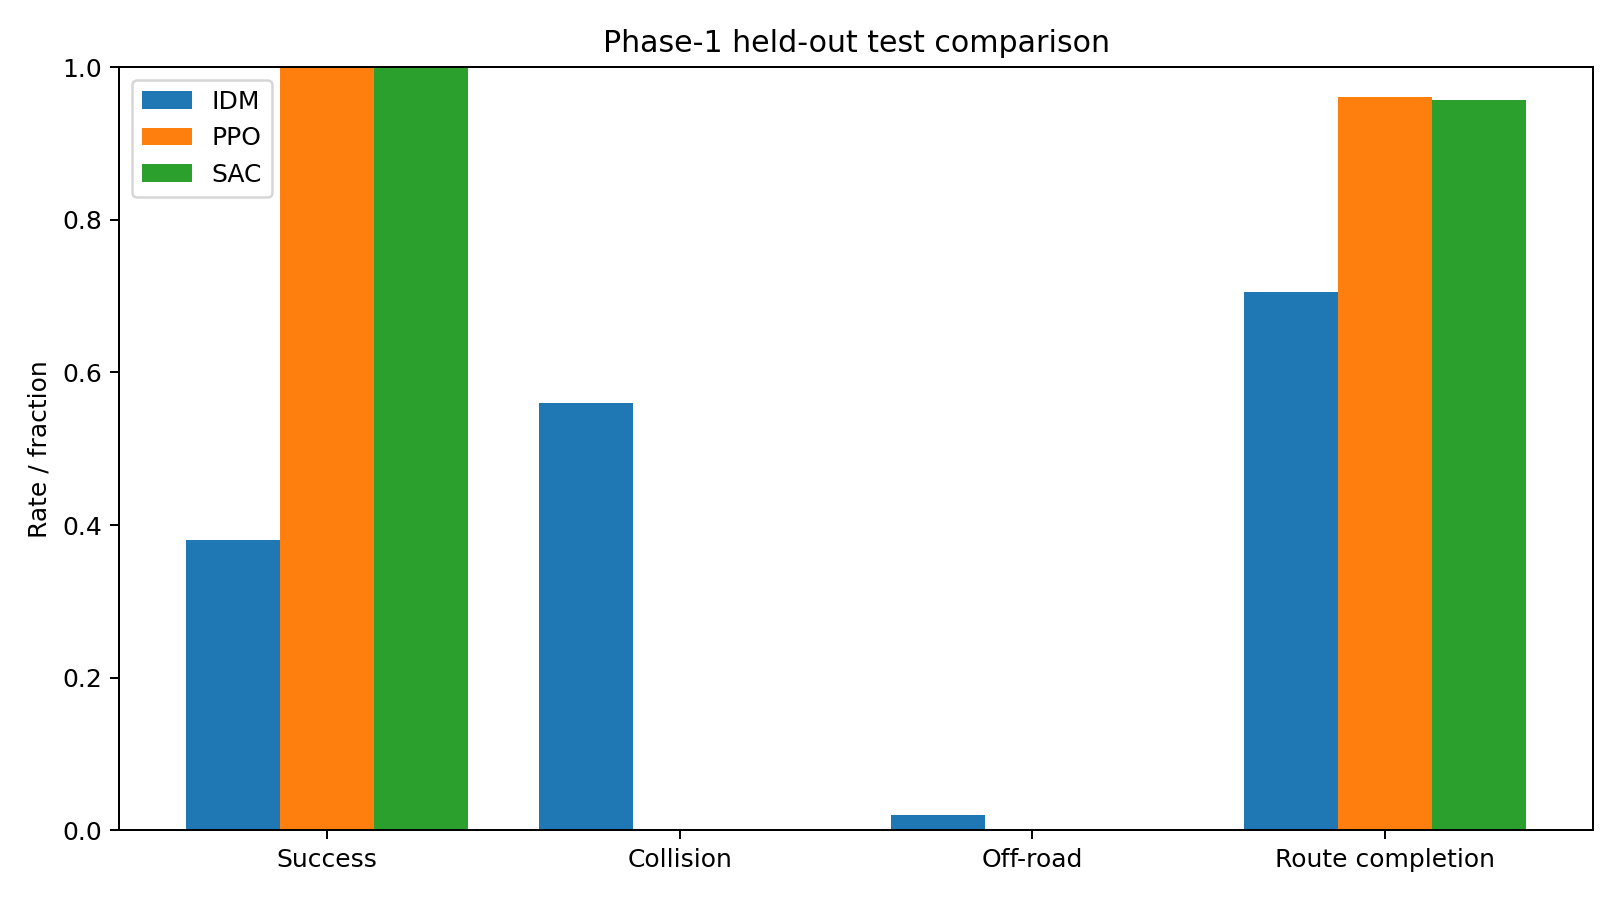

Copied to Drive: /content/drive/MyDrive/SafeDrive/runs/phase1_comparison.csv
Copied to Drive: /content/drive/MyDrive/SafeDrive/runs/phase1_comparison.json
Copied to Drive: /content/drive/MyDrive/SafeDrive/runs/phase1_comparison.png
Copied to Drive: /content/drive/MyDrive/SafeDrive/runs/phase1_training_returns.png


In [15]:
import pandas as pd
from IPython.display import Image, display

!python -m scripts.compare_runs --phase1
require_shell_success("Phase-1 comparison")

comparison_csv = REPO_DIR / "runs" / "phase1_comparison.csv"
comparison_json = REPO_DIR / "runs" / "phase1_comparison.json"
comparison_png = REPO_DIR / "runs" / "phase1_comparison.png"
display(pd.read_csv(comparison_csv))
show_json(comparison_json)
display(Image(filename=str(comparison_png)))

for path in [comparison_csv, comparison_json, comparison_png]:
    copy_to_drive(path)
training_comparison = REPO_DIR / "runs" / "phase1_training_returns.png"
if training_comparison.exists():
    copy_to_drive(training_comparison)

INFO: Runtime: Python 3.12.13 | CUDA available | GPU NVIDIA L4
INFO: Phase-1 comparison written: runs/phase1_comparison.csv
INFO: Comparison plot written: runs/phase1_comparison.png
INFO: Training comparison written: runs/phase1_training_returns.png


,name,episodes,mean_return,std_return,mean_length,success_rate,collision_rate,out_of_road_rate,timeout_or_max_step_rate,mean_cost,mean_route_completion,mean_speed_km_h,run_dir,summary_path
0,IDM,50,394.488521,241.378332,526.26,0.50,0.28,0.20,0.02,0.48,0.696618,27.046089,/content/safedrive/runs/20260721_023109_idm_ba...,/content/safedrive/runs/20260721_023109_idm_ba...
1,PPO,50,254.318737,161.518255,578.56,0.16,0.12,0.54,0.18,0.66,0.597896,23.863502,/content/safedrive/runs/20260721_023556_ppo_mv...,/content/safedrive/runs/20260721_023556_ppo_mv...
2,SAC,50,63.006623,65.336449,905.16,0.00,0.00,0.14,0.86,0.14,0.174585,4.218184,/content/safedrive/runs/20260721_032424_sac_mv...,/content/safedrive/runs/20260721_032424_sac_mv...


{
  "generated_at_utc": "2026-07-21T06:34:17.836754+00:00",
  "experiments": [
    {
      "name": "IDM",
      "episodes": 50,
      "mean_return": 394.48852090106493,
      "std_return": 241.37833241859207,
      "mean_length": 526.26,
      "success_rate": 0.5,
      "collision_rate": 0.28,
      "out_of_road_rate": 0.2,
      "timeout_or_max_step_rate": 0.02,
      "mean_cost": 0.48,
      "mean_route_completion": 0.6966180358737663,
      "mean_speed_km_h": 27.04608873858742,
      "run_dir": "/content/safedrive/runs/20260721_023109_idm_baseline_seed0",
      "summary_path": "/content/safedrive/runs/20260721_023109_idm_baseline_seed0/eval/idm_unseen_summary.json"
    },
    {
      "name": "PPO",
      "episodes": 50,
      "mean_return": 254.3187371043007,
      "std_return": 161.51825477257682,
      "mean_length": 578.56,
      "success_rate": 0.16,
      "collision_rate": 0.12,
      "out_of_road_rate": 0.54,
      "timeout_or_max_step_rate": 0.18,
      "mean_cost": 0.66,
   

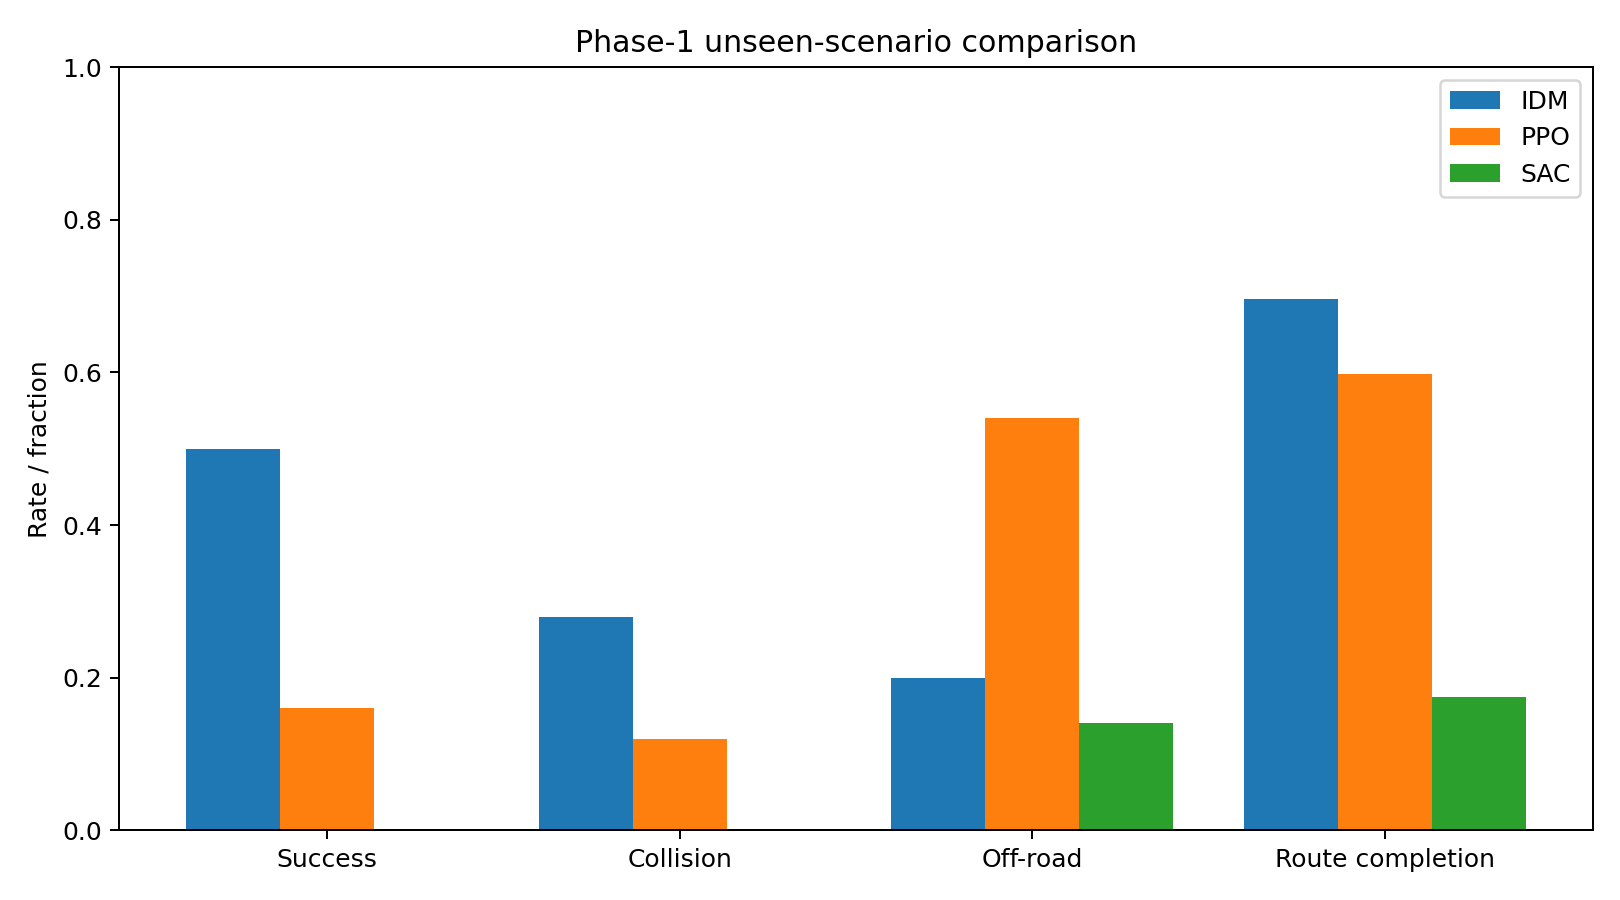

Copied to Drive: /content/drive/MyDrive/SafeDrive/runs/phase1_comparison.csv
Copied to Drive: /content/drive/MyDrive/SafeDrive/runs/phase1_comparison.json
Copied to Drive: /content/drive/MyDrive/SafeDrive/runs/phase1_comparison.png
Copied to Drive: /content/drive/MyDrive/SafeDrive/runs/phase1_training_returns.png


In [13]:
import pandas as pd
from IPython.display import Image, display

!python -m scripts.compare_runs --phase1
require_shell_success("Phase-1 comparison")

comparison_csv = REPO_DIR / "runs" / "phase1_comparison.csv"
comparison_json = REPO_DIR / "runs" / "phase1_comparison.json"
comparison_png = REPO_DIR / "runs" / "phase1_comparison.png"
display(pd.read_csv(comparison_csv))
show_json(comparison_json)
display(Image(filename=str(comparison_png)))

for path in [comparison_csv, comparison_json, comparison_png]:
    copy_to_drive(path)
training_comparison = REPO_DIR / "runs" / "phase1_training_returns.png"
if training_comparison.exists():
    copy_to_drive(training_comparison)

## 13. Build the LaTeX report

In [14]:
if shutil.which("latexmk"):
    !latexmk -pdf -interaction=nonstopmode -halt-on-error reports/main.tex
    require_shell_success("LaTeX report build")
else:
    print("latexmk is not installed in this runtime. Build locally from the repository root with:")
    print("latexmk -pdf -interaction=nonstopmode -halt-on-error reports/main.tex")

report_pdf = REPO_DIR / "reports" / "main.pdf"
if report_pdf.exists():
    copy_to_drive(report_pdf, category="reports")

latexmk is not installed in this runtime. Build locally from the repository root with:
latexmk -pdf -interaction=nonstopmode -halt-on-error reports/main.tex


## 14. Final artifact sync

In [16]:
(DRIVE_PROJECT / "runs").mkdir(parents=True, exist_ok=True)
(DRIVE_PROJECT / "reports").mkdir(parents=True, exist_ok=True)

if shutil.which("rsync"):
    !rsync -a "{REPO_DIR}/runs/" "{DRIVE_PROJECT}/runs/"
    require_shell_success("Run artifact sync")
    !rsync -a "{REPO_DIR}/reports/" "{DRIVE_PROJECT}/reports/"
    require_shell_success("Report artifact sync")
else:
    shutil.copytree(REPO_DIR / "runs", DRIVE_PROJECT / "runs", dirs_exist_ok=True)
    shutil.copytree(REPO_DIR / "reports", DRIVE_PROJECT / "reports", dirs_exist_ok=True)

print(f"Final artifact sync complete: {DRIVE_PROJECT}")

Final artifact sync complete: /content/drive/MyDrive/SafeDrive


## Finished

The detailed execution record is inside each run's `logs/` directory and `run_metadata.json`. Disconnect the Colab runtime when finished so it does not continue consuming compute units.